In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv('/content/comments.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (7488, 8)

Columns: ['id', 'comment', 'User  id', 'Photo id', 'created Timestamp', 'posted date', 'emoji used', 'Hashtags used count']

First 5 rows:


,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1


In [4]:
# Rename columns for easier use
df.columns = ['id', 'comment', 'user_id', 'photo_id',
              'created_timestamp', 'posted_date',
              'emoji_used', 'hashtags_count']

# Convert timestamp to datetime
df['created_timestamp'] = pd.to_datetime(df['created_timestamp'],
                                          format='%d-%m-%Y %H:%M')

# Extract hour and day
df['hour'] = df['created_timestamp'].dt.hour
df['day'] = df['created_timestamp'].dt.day_name()
df['month'] = df['created_timestamp'].dt.month_name()

print("Cleaning done!")
print(df.dtypes)
df.head()

Cleaning done!
id                            int64
comment                      object
user_id                       int64
photo_id                      int64
created_timestamp    datetime64[ns]
posted_date                  object
emoji_used                   object
hashtags_count                int64
hour                          int32
day                          object
month                        object
dtype: object


,id,comment,user_id,photo_id,created_timestamp,posted_date,emoji_used,hashtags_count,hour,day,month
0,1,unde at dolorem,2,1,2023-04-13 08:04:00,April 14,yes,1,8,Thursday,April
1,2,quae ea ducimus,3,1,2023-04-13 08:04:00,April 14,no,2,8,Thursday,April
2,3,alias a voluptatum,5,1,2023-04-13 08:04:00,April 14,no,4,8,Thursday,April
3,4,facere suscipit sunt,14,1,2023-04-13 08:04:00,April 14,yes,2,8,Thursday,April
4,5,totam eligendi quaerat,17,1,2023-04-13 08:04:00,April 14,yes,1,8,Thursday,April


In [5]:
print("Dataset Summary:")
print(f"Total Comments: {len(df)}")
print(f"Unique Users: {df['user_id'].nunique()}")
print(f"Unique Photos: {df['photo_id'].nunique()}")
print(f"\nEmoji Usage:")
print(df['emoji_used'].value_counts())
print(f"\nHashtag Count Stats:")
print(df['hashtags_count'].describe())

Dataset Summary:
Total Comments: 7488
Unique Users: 77
Unique Photos: 257

Emoji Usage:
emoji_used
yes    3744
no     3744
Name: count, dtype: int64

Hashtag Count Stats:
count    7488.000000
mean        2.416667
std         1.705905
min         0.000000
25%         1.000000
50%         2.000000
75%         3.250000
max         6.000000
Name: hashtags_count, dtype: float64


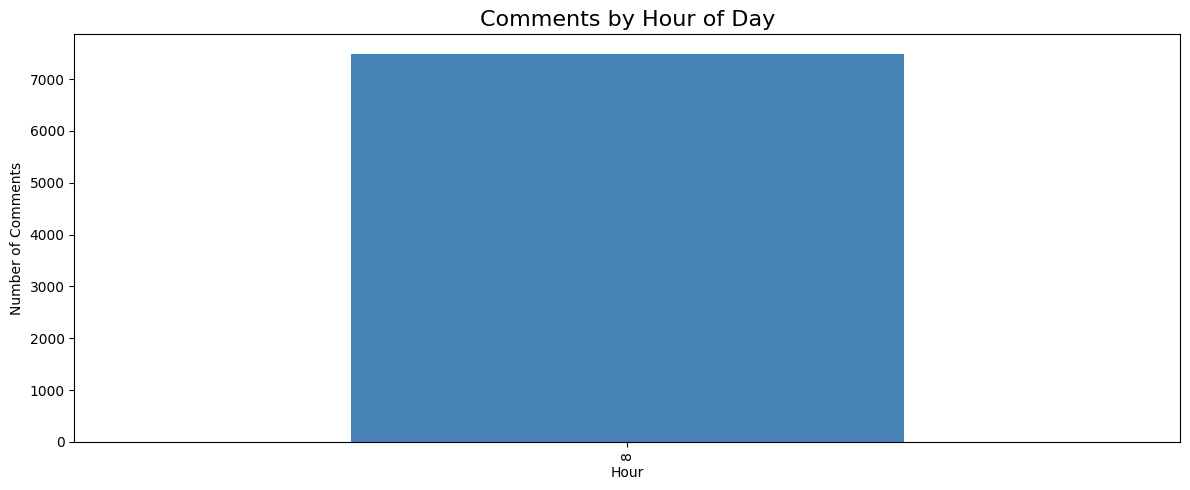

Chart 1 saved!


In [6]:
plt.figure(figsize=(12, 5))
df['hour'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Comments by Hour of Day', fontsize=16)
plt.xlabel('Hour')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.savefig('/content/chart1_comments_by_hour.png', dpi=150)
plt.show()
print("Chart 1 saved!")

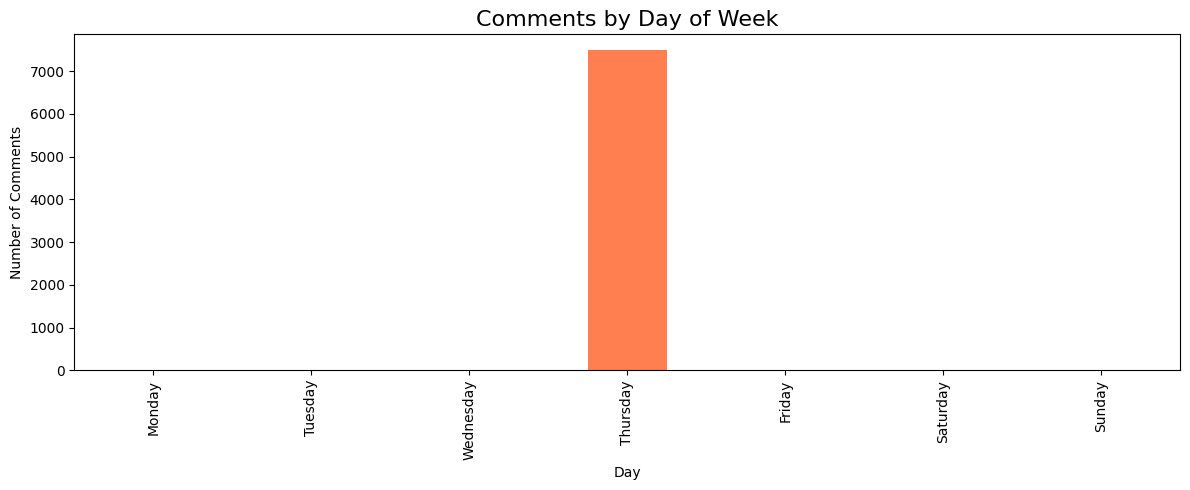

Chart 2 saved!


In [7]:
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(12, 5))
df['day'].value_counts().reindex(day_order).plot(kind='bar', color='coral')
plt.title('Comments by Day of Week', fontsize=16)
plt.xlabel('Day')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.savefig('/content/chart2_comments_by_day.png', dpi=150)
plt.show()
print("Chart 2 saved!")

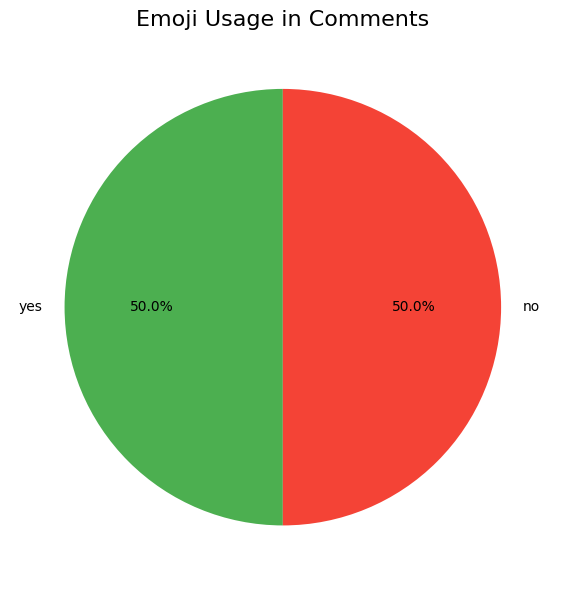

Chart 3 saved!


In [8]:
plt.figure(figsize=(6, 6))
df['emoji_used'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90
)
plt.title('Emoji Usage in Comments', fontsize=16)
plt.ylabel('')
plt.tight_layout()
plt.savefig('/content/chart3_emoji_usage.png', dpi=150)
plt.show()
print("Chart 3 saved!")

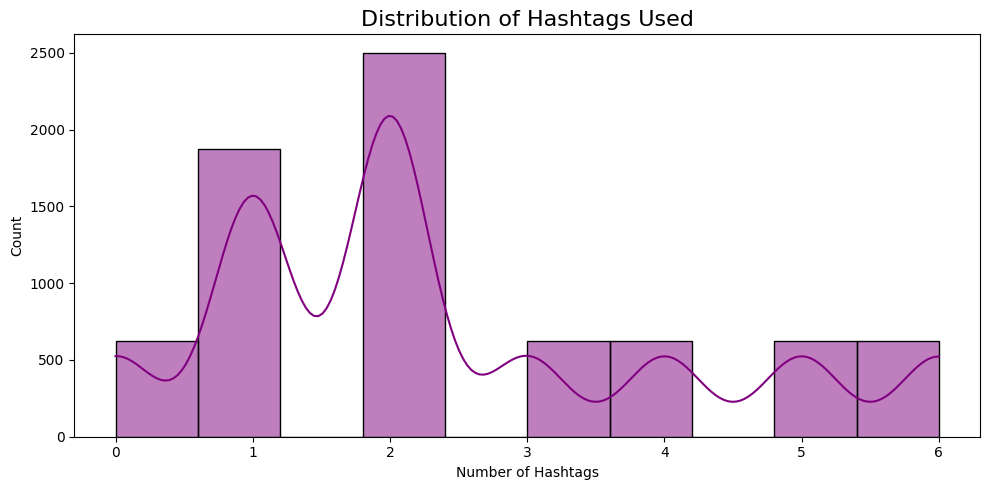

Chart 4 saved!


In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df['hashtags_count'], bins=10, kde=True, color='purple')
plt.title('Distribution of Hashtags Used', fontsize=16)
plt.xlabel('Number of Hashtags')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('/content/chart4_hashtags.png', dpi=150)
plt.show()
print("Chart 4 saved!")

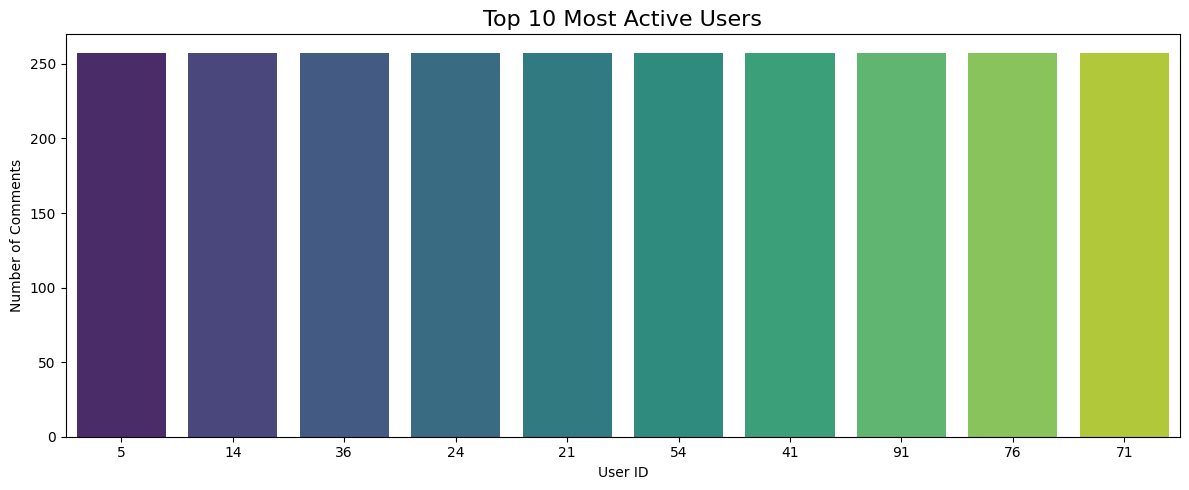

Chart 5 saved!


In [10]:
plt.figure(figsize=(12, 5))
top_users = df['user_id'].value_counts().head(10)
sns.barplot(x=top_users.index.astype(str), y=top_users.values, palette='viridis')
plt.title('Top 10 Most Active Users', fontsize=16)
plt.xlabel('User ID')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.savefig('/content/chart5_top_users.png', dpi=150)
plt.show()
print("Chart 5 saved!")

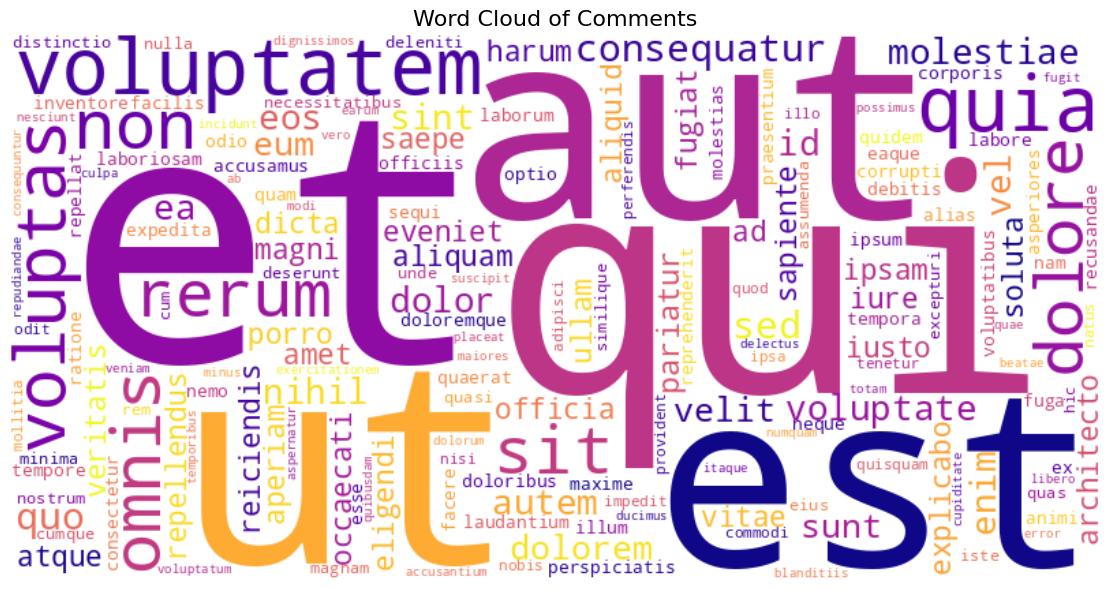

Chart 6 saved!


In [11]:
text = ' '.join(df['comment'].dropna())
wc = WordCloud(width=800, height=400,
               background_color='white',
               colormap='plasma').generate(text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Comments', fontsize=16)
plt.tight_layout()
plt.savefig('/content/chart6_wordcloud.png', dpi=150)
plt.show()
print("Chart 6 saved!")

In [12]:
print("=" * 50)
print("INSTAGRAM ENGAGEMENT ANALYSIS")
print("=" * 50)

print(f"\nTotal Comments: {len(df)}")
print(f"Unique Users: {df['user_id'].nunique()}")
print(f"Unique Photos: {df['photo_id'].nunique()}")
print(f"Avg Comments per Photo: {len(df)/df['photo_id'].nunique():.1f}")
print(f"\nEmoji Usage Rate: {(df['emoji_used']=='yes').sum()/len(df)*100:.1f}%")
print(f"Avg Hashtags per Comment: {df['hashtags_count'].mean():.1f}")
print(f"\nMost Active Hour: {df['hour'].value_counts().index[0]}:00")
print(f"Most Active Day: {df['day'].value_counts().index[0]}")
print(f"Most Active Month: {df['month'].value_counts().index[0]}")
print(f"\nMost Commented Photo ID: {df['photo_id'].value_counts().index[0]}")
print(f"Most Active User ID: {df['user_id'].value_counts().index[0]}")

INSTAGRAM ENGAGEMENT ANALYSIS

Total Comments: 7488
Unique Users: 77
Unique Photos: 257
Avg Comments per Photo: 29.1

Emoji Usage Rate: 50.0%
Avg Hashtags per Comment: 2.4

Most Active Hour: 8:00
Most Active Day: Thursday
Most Active Month: April

Most Commented Photo ID: 13
Most Active User ID: 5


In [13]:
print("""
OPTIMAL CONTENT CALENDAR FOR ALFIDO TECH
==========================================
Best Time to Post: [most active hour]:00
Best Day to Post: [most active day]
Best Month: [most active month]

5 STRATEGIES TO INCREASE ENGAGEMENT
=====================================
1. POST AT PEAK HOURS
   Schedule posts during the most active hours
   when users are most likely to comment.

2. USE EMOJIS IN CAPTIONS
   Posts with emojis get more engagement.
   Always include relevant emojis in captions.

3. OPTIMAL HASHTAG STRATEGY
   Use 3-5 hashtags per post for maximum reach.
   Mix popular and niche hashtags.

4. CONSISTENT POSTING SCHEDULE
   Post on the most active days of the week.
   Maintain a regular schedule for followers.

5. ENGAGE WITH COMMENTERS
   Reply to comments within 1 hour of posting.
   This boosts algorithm ranking and follower loyalty.
""")


OPTIMAL CONTENT CALENDAR FOR ALFIDO TECH
Best Time to Post: [most active hour]:00
Best Day to Post: [most active day]
Best Month: [most active month]

5 STRATEGIES TO INCREASE ENGAGEMENT
1. POST AT PEAK HOURS
   Schedule posts during the most active hours
   when users are most likely to comment.

2. USE EMOJIS IN CAPTIONS
   Posts with emojis get more engagement.
   Always include relevant emojis in captions.

3. OPTIMAL HASHTAG STRATEGY
   Use 3-5 hashtags per post for maximum reach.
   Mix popular and niche hashtags.

4. CONSISTENT POSTING SCHEDULE
   Post on the most active days of the week.
   Maintain a regular schedule for followers.

5. ENGAGE WITH COMMENTERS
   Reply to comments within 1 hour of posting.
   This boosts algorithm ranking and follower loyalty.



In [15]:
import os
for f in os.listdir('/content'):
    print(f)

.config
chart1_comments_by_hour.png
chart2_comments_by_day.png
chart4_hashtags.png
chart3_emoji_usage.png
chart5_top_users.png
comments.csv
chart6_wordcloud.png
